In [1]:
# Need to fix
%pip install pylr2

Note: you may need to restart the kernel to use updated packages.


# Google Sheets for OWLR Data

 https://docs.google.com/spreadsheets/d/1FgQRhw9HWl-7XXXsmWhnBUNeneZqLjEzmYZBD_2KLuo/edit?gid=0#gid=0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from pylr2 import regress2

warnings.filterwarnings('ignore', message="Could not infer format")

# File Paths and Processing

The following code begins with defining file paths and ensures it is using the correct columns for rainfall data. Data is loaded and processed to ensure rainfall is in the same units and there is correct summation of rainfall events. 



In [20]:
filepath = os.path.join('Data', 'precip_CORMP_04132026.csv')
df_full = pd.read_csv(filepath, header = None, parse_dates = [1], skiprows=6)
df_full.columns = ['Datetime Transmission','Rainfall (mm)', 'NaN']
df_full.head()

,Datetime Transmission,Rainfall (mm),NaN
0,Time (America/New_York),CMSDOCK Rain (last 15 min) (in),CMSDOCK Rain (last 15 min) (in) quality
1,2025-12-19 00:00,0.07,not evaluated
2,2025-12-19 00:15,0.04,not evaluated
3,2025-12-19 00:30,0.02,not evaluated
4,2025-12-19 00:45,0.01,not evaluated


In [18]:
filepath = os.path.join('Data', 'precip_Davis_04132026.csv')
df_full = pd.read_csv(filepath, header = None, parse_dates = [1], skiprows=7)
df_full.columns = ['Datetime Transmission','Rainfall (mm)']
df_full.head()

,Datetime Transmission,Rainfall (mm)
0,12/19/25 12:15 AM,1.0
1,12/19/25 12:30 AM,0.5
2,12/19/25 12:45 AM,0.3
3,12/19/25 1:00 AM,0.0
4,12/19/25 1:15 AM,0.0


In [14]:
filepath = os.path.join('Data', 'OWLR_CMS_04152026.csv')
df_full = pd.read_csv(filepath, header = None, parse_dates = [1])
df_full.columns = ['Device_ID', 'Datetime Transmission', 'Blank', 'Event', 'Unix Time', 'Distance (cm)', 'Rainfall (mm)', 'Battery (V)', 'Charge (%)']
df_full.head()

,Device_ID,Datetime Transmission,Blank,Event,Unix Time,Distance (cm),Rainfall (mm),Battery (V),Charge (%)
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,e00fce681282837e5d0586e0,2025-11-25 09:25:36,NaN,rainfall,1.764081e+09,60.36389,0.0,0.17,0.00
2,e00fce681282837e5d0586e0,2025-11-25 09:36:14,NaN,rainfall,9.466848e+08,27.66250,0.0,0.17,91.96
3,e00fce681282837e5d0586e0,2025-11-25 09:41:31,NaN,rainfall,9.466848e+08,39.67778,0.0,0.17,92.60
4,e00fce681282837e5d0586e0,2025-11-25 10:00:52,NaN,rainfall,1.764083e+09,164.17084,1.4,0.05,83.03


In [79]:
# Define file paths and filter period
cormp_file = 'Data/precip_CORMP_04132026.csv'
davis_file = 'Data/precip_Davis_04132026.csv'
owlr_file = 'Data/OWLR_CMS_04132026.csv'

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-04-13 08:00')

def keep_analysis_period(df):
    return df[(df['datetime'] >= start) & (df['datetime'] <= end)].reset_index(drop=True)

def load_cormp(filepath):
    df = pd.read_csv(filepath, skiprows=6)
    df = df.iloc[:, [0, 1]].copy()
    df.columns = ['datetime', 'rain_mm']
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df['rain_mm'] = pd.to_numeric(df['rain_mm'], errors='coerce')
    # CORMP rainfall is in inches; convert to mm.
    df['rain_mm'] = df['rain_mm'] * 25.4
    df = df[['datetime', 'rain_mm']].dropna()
    return keep_analysis_period(df.set_index('datetime').resample('h').sum().reset_index())

def load_davis(filepath):
    df = pd.read_csv(filepath, skiprows=6)
    df.columns = ['datetime', 'rain_mm']
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df['rain_mm'] = pd.to_numeric(df['rain_mm'], errors='coerce')
    df = df[['datetime', 'rain_mm']].dropna()
    return keep_analysis_period(df.set_index('datetime').resample('h').sum().reset_index())

def load_owlr(filepath):
    df = pd.read_csv(filepath, header=None)
    df.columns = ['device_id', 'datetime', 'blank', 'event', 'payload']
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df['rain_mm'] = pd.to_numeric(df['payload'].str.split(',').str[2], errors='coerce')
    df = df[['datetime', 'rain_mm']].dropna()
    return keep_analysis_period(df)

def prepare_sensor(df, rain_col):
    prepared = df[['datetime', 'rain_mm']].copy()
    prepared['datetime'] = pd.to_datetime(prepared['datetime']).dt.floor('h')
    return prepared.rename(columns={'rain_mm': rain_col})

print('Loading and processing rainfall data...')
cormp = load_cormp(cormp_file)
davis = load_davis(davis_file)
owlr = load_owlr(owlr_file)

tr525 = prepare_sensor(cormp, 'tr525_mm')
aerocone = prepare_sensor(davis, 'aerocone_mm')
owlr_hourly = prepare_sensor(owlr, 'owlr_mm')
rainfall_all = tr525.merge(aerocone, on='datetime', how='outer').merge(owlr_hourly, on='datetime', how='outer')

print(f'  TR-525l: {len(cormp)} hourly records')
print(f'  Davis: {len(davis)} hourly records')
print(f'  OWLR: {len(owlr)} hourly records')
print(f'  Combined comparison table: {rainfall_all.shape}')

Loading and processing rainfall data...
  TR-525l: 2760 hourly records
  Davis: 2760 hourly records
  OWLR: 2753 hourly records
  Combined comparison table: (2765, 4)


In [68]:
# Reusable helpers for repeated event analysis
def filter_hourly_window(df, start_time, end_time):
    start_time = pd.to_datetime(start_time)
    end_time = pd.to_datetime(end_time)
    return df[(df['datetime'] >= start_time) & (df['datetime'] <= end_time)].reset_index(drop=True)

def build_event_frame(start_time, end_time, calibrate_owlr=False):
    event_df = filter_hourly_window(rainfall_all, start_time, end_time).copy()
    event_df = event_df.rename(columns={
        'tr525_mm': 'rain_mm_cormp',
        'aerocone_mm': 'rain_mm_davis',
        'owlr_mm': 'rain_mm_owlr'
    })
    if calibrate_owlr:
        coeff_m = globals().get('m')
        coeff_b = globals().get('b')
        if coeff_m is None or coeff_b is None:
            raise ValueError('Run the OWLR calibration cell first to compute calibration coefficients m and b.')
        event_df['rain_mm_owlr_cal'] = ((coeff_m * event_df['rain_mm_owlr']) + coeff_b).clip(lower=0)
    return event_df

def paired_metrics(df, x_col, y_col):
    pair = df[[x_col, y_col]].dropna()
    if pair.empty:
        return pair, np.nan, np.nan
    corr = pair[x_col].corr(pair[y_col])
    return pair, corr, corr**2

def add_best_fit_line(ax, pair, x_col, y_col, color, label, linestyle='--'):
    if len(pair) < 2:
        return
    slope, intercept = np.polyfit(pair[x_col], pair[y_col], 1)
    x_line = np.array([pair[x_col].min(), pair[x_col].max()])
    ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=2, alpha=0.8, linestyle=linestyle, label=label)

def print_column_summary(df, label, column_name):
    if column_name in df.columns and df[column_name].notna().any():
        print(f"{label} - Min: {df[column_name].min():.4f}, Max: {df[column_name].max():.4f}, Mean: {df[column_name].mean():.4f}")

def run_event_analysis(analysis_title, event_label, event_df, plot_title, owlr_col='rain_mm_owlr', owlr_label='OWLR'):
    print('=' * 70)
    print(analysis_title)
    print('=' * 70)

    print(f"\n{event_label} Data:")
    print(f"  CORMP records: {event_df['rain_mm_cormp'].notna().sum()}")
    print(f"  Davis records: {event_df['rain_mm_davis'].notna().sum()}")
    print(f"  {owlr_label} records: {event_df[owlr_col].notna().sum()}")
    print(f"\nMerged dataset shape: {event_df.shape}")

    owlr_pair, _, owlr_r2 = paired_metrics(event_df, 'rain_mm_cormp', owlr_col)
    davis_pair, _, davis_r2 = paired_metrics(event_df, 'rain_mm_cormp', 'rain_mm_davis')

    print('\nGenerating scatter plot...')
    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    cormp_pair = event_df[['rain_mm_cormp']].dropna()
    if not cormp_pair.empty:
        ax.scatter(
            cormp_pair['rain_mm_cormp'],
            cormp_pair['rain_mm_cormp'],
            s=80,
            alpha=0.7,
            color='crimson',
            label='TR525l',
            marker='s'
        )
        print(f"  Plotted {len(cormp_pair)} TR525l data points")
        add_best_fit_line(ax, cormp_pair.assign(rain_mm_ref=cormp_pair['rain_mm_cormp']), 'rain_mm_cormp', 'rain_mm_ref', 'crimson', 'TR525l Best-Fit Line', linestyle='-')

    if not davis_pair.empty:
        ax.scatter(
            davis_pair['rain_mm_cormp'],
            davis_pair['rain_mm_davis'],
            s=80,
            alpha=0.7,
            color='steelblue',
            label='Aerocone',
            marker='o'
        )
        print(f"  Plotted {len(davis_pair)} Aerocone data points")
        add_best_fit_line(ax, davis_pair, 'rain_mm_cormp', 'rain_mm_davis', 'steelblue', 'Aerocone Best-Fit Line')

    if not owlr_pair.empty:
        ax.scatter(
            owlr_pair['rain_mm_cormp'],
            owlr_pair[owlr_col],
            s=80,
            alpha=0.7,
            color='darkgreen',
            label=owlr_label,
            marker='^'
        )
        print(f"  Plotted {len(owlr_pair)} {owlr_label} data points")
        add_best_fit_line(ax, owlr_pair, 'rain_mm_cormp', owlr_col, 'darkgreen', f'{owlr_label} Best-Fit Line')

    annotation_lines = []
    if pd.notna(owlr_r2):
        annotation_lines.append(f"TR525l vs {owlr_label} R² = {owlr_r2:.4f} (N={len(owlr_pair)})")
    if pd.notna(davis_r2):
        annotation_lines.append(f"TR525l vs Aerocone R² = {davis_r2:.4f} (N={len(davis_pair)})")
    if annotation_lines:
        ax.text(
            0.95,
            0.95,
            '\n'.join(annotation_lines),
            transform=ax.transAxes,
            fontsize=11,
            va='top',
            ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
        )

    plt.xlabel('TR525l Rainfall (mm)', fontsize=12, fontweight='bold')
    plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
    plt.title(plot_title, fontsize=13, fontweight='bold')
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\n' + '=' * 70)
    print(f'Summary Statistics for {event_label}:')
    print('=' * 70)
    print_column_summary(event_df, 'CORMP', 'rain_mm_cormp')
    print_column_summary(event_df, 'Davis', 'rain_mm_davis')
    print_column_summary(event_df, owlr_label, owlr_col)

# Type 2 Regression Model Steps 
This compares rainfall measurements from three sensors using reduced major axis (Type II) regression

In [69]:
# Use the sensor-specific hourly tables created in the loading cell
paired = rainfall_all[['datetime', 'tr525_mm', 'owlr_mm']].dropna()
paired_aero = rainfall_all[['datetime', 'tr525_mm', 'aerocone_mm']].dropna()

# Validate sufficient data for regression
if len(paired) < 2 or len(paired_aero) < 2:
    raise ValueError('Not enough overlapping hourly points for Type II regression.')

# Extract variables for regression
x = paired['tr525_mm'].to_numpy()
y = paired['owlr_mm'].to_numpy()
x_aero = paired_aero['tr525_mm'].to_numpy()
y_aero = paired_aero['aerocone_mm'].to_numpy()

# Perform Type II regression
This regression assumes that all variables have some sort of error. 

In [70]:

fit = regress2(x, y, _method_type_2='reduced major axis')
slope = fit.get('slope', np.nan)
intercept = fit.get('intercept', np.nan)
r = fit.get('r', np.corrcoef(x, y)[0, 1])
r2 = r**2 if np.isfinite(r) else np.nan

fit_aero = regress2(x_aero, y_aero, _method_type_2='reduced major axis')
slope_aero = fit_aero.get('slope', np.nan)
intercept_aero = fit_aero.get('intercept', np.nan)
r_aero = fit_aero.get('r', np.corrcoef(x_aero, y_aero)[0, 1])
r2_aero = r_aero**2 if np.isfinite(r_aero) else np.nan

# Calculate residuals and performance metrics
y_hat = slope * x + intercept
residuals = y - y_hat
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
resid_mean = np.mean(residuals)
resid_std = np.std(residuals, ddof=1)

# Print regression results
print(f'Overlapping hourly points: OWLR={len(paired)}, Aerocone={len(paired_aero)}')
print(f'\nType II RMA regression equations:')
print(f'  OWLR = {slope:.4f} × TR-525l + {intercept:.4f}')
print(f'  Aerocone = {slope_aero:.4f} × TR-525l + {intercept_aero:.4f}')
print(f'\nRegression fit statistics:')
print(f'  OWLR: r = {r:.4f}, r² = {r2:.4f}')
print(f'  Aerocone: r = {r_aero:.4f}, r² = {r2_aero:.4f}')
print(f'\nOWLR residual statistics (mm):')
print(f'  Mean: {resid_mean:.4f} | Std Dev: {resid_std:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}')



Overlapping hourly points: OWLR=2753, Aerocone=2765

Type II RMA regression equations:
  OWLR = 18.0687 × TR-525l + -0.0123
  Aerocone = 29.5578 × TR-525l + -0.0064

Regression fit statistics:
  OWLR: r = 0.3844, r² = 0.1478
  Aerocone: r = 0.6435, r² = 0.4141

OWLR residual statistics (mm):
  Mean: -0.0000 | Std Dev: 0.4804 | MAE: 0.0585 | RMSE: 0.4803


# Plot of the Regression scatter plot and residual diagnostics


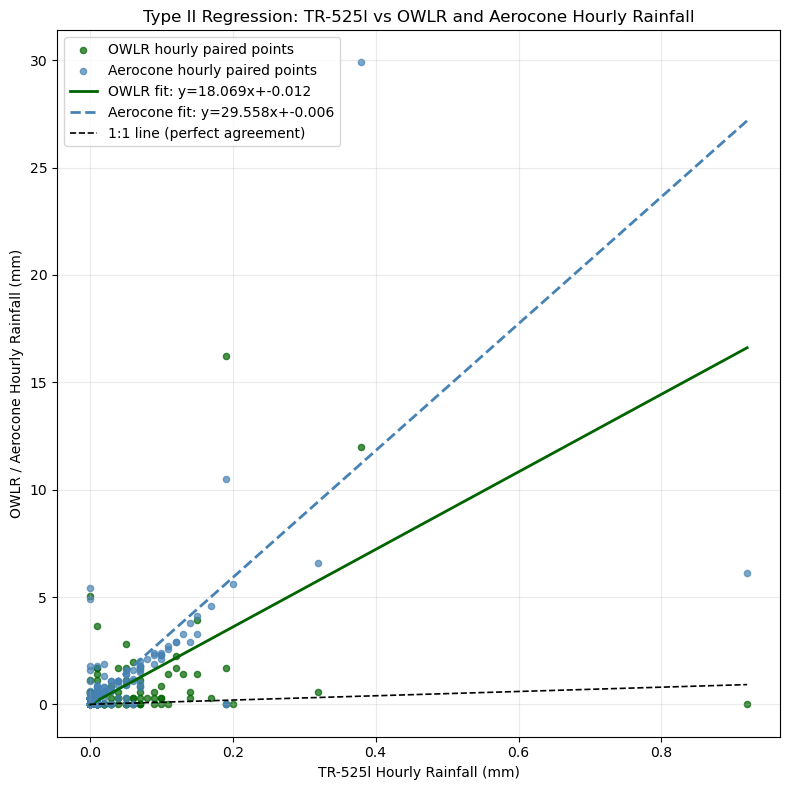

In [71]:
plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=20, alpha=0.7, label='OWLR hourly paired points', color='darkgreen')
plt.scatter(x_aero, y_aero, s=20, alpha=0.7, label='Aerocone hourly paired points', color='steelblue')

xmin = min(np.nanmin(x), np.nanmin(x_aero))
xmax = max(np.nanmax(x), np.nanmax(x_aero))
xline = np.linspace(xmin, xmax, 200)
plt.plot(xline, slope * xline + intercept, color='darkgreen', lw=2,
         label=f'OWLR fit: y={slope:.3f}x+{intercept:.3f}')
plt.plot(xline, slope_aero * xline + intercept_aero, color='steelblue', lw=2, ls='--',
         label=f'Aerocone fit: y={slope_aero:.3f}x+{intercept_aero:.3f}')
plt.plot(xline, xline, color='black', ls='--', lw=1.2, label='1:1 line (perfect agreement)')

plt.xlabel('TR-525l Hourly Rainfall (mm)')
plt.ylabel('OWLR / Aerocone Hourly Rainfall (mm)')
plt.title('Type II Regression: TR-525l vs OWLR and Aerocone Hourly Rainfall')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


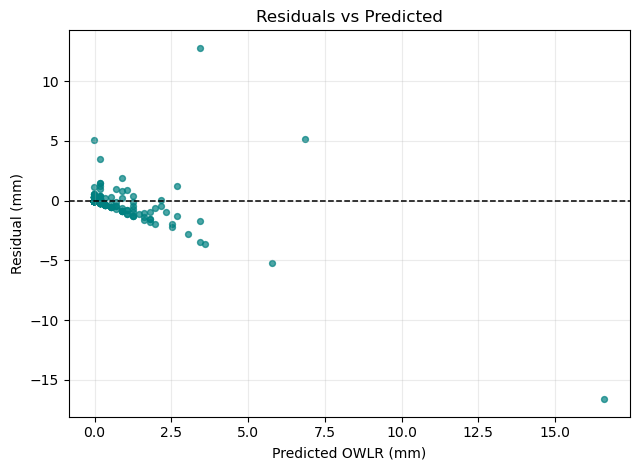

In [72]:
# Plot 2: Residuals vs predicted values (for OWLR comparison)
plt.figure(figsize=(6.5, 4.8))
plt.scatter(y_hat, residuals, s=18, alpha=0.7, color='teal')
plt.axhline(0, color='black', linestyle='--', linewidth=1.1)
plt.xlabel('Predicted OWLR (mm)')
plt.ylabel('Residual (mm)')
plt.title('Residuals vs Predicted')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

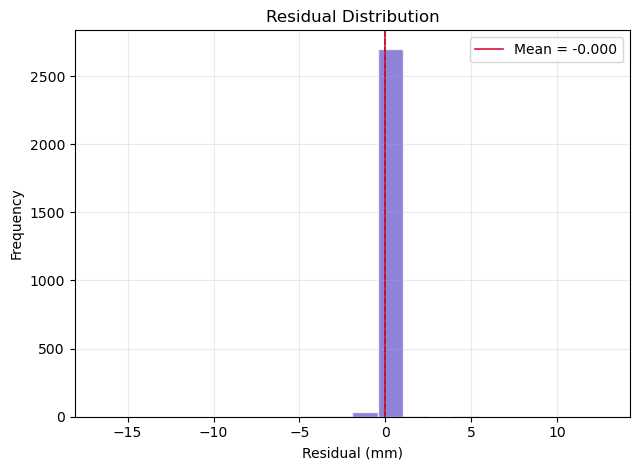

In [73]:
# Plot 3: Residual distribution (for OWLR comparison)
plt.figure(figsize=(6.5, 4.8))
plt.hist(residuals, bins=20, color='slateblue', alpha=0.75, edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=1.1)
plt.axvline(resid_mean, color='crimson', linestyle='-', linewidth=1.2, label=f'Mean = {resid_mean:.3f}')
plt.xlabel('Residual (mm)')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Full Period Scatter Plot

This cell plots a full period scatter plot of all three sensors. 



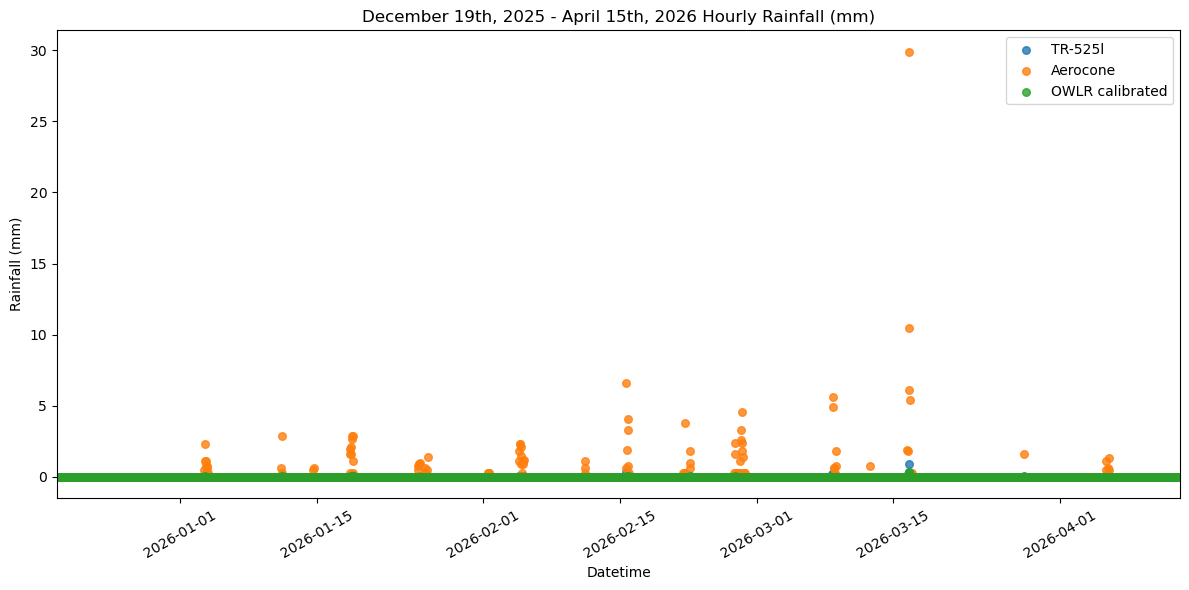

In [74]:
# Full period scatter plot with calibrated OWLR points
coeff_m = globals().get('m')
coeff_b = globals().get('b')
if coeff_m is None or coeff_b is None:
    raise ValueError('Run Cell 25 first to compute calibration coefficients m and b.')

# Apply calibration to full-period OWLR data: OWLR_cal = m * OWLR_raw + b
owlr_calibrated = owlr.copy()
owlr_calibrated['rain_mm_cal'] = (coeff_m * owlr_calibrated['rain_mm']) + coeff_b
owlr_calibrated['rain_mm_cal'] = owlr_calibrated['rain_mm_cal'].clip(lower=0)

plt.figure(figsize=(12, 6))
if not cormp.empty:
    plt.scatter(cormp['datetime'], cormp['rain_mm'], label='TR-525l', s=30, alpha=0.8)
if not davis.empty:
    plt.scatter(davis['datetime'], davis['rain_mm'], label='Aerocone', s=30, alpha=0.8)
if not owlr_calibrated.empty:
    plt.scatter(owlr_calibrated['datetime'], owlr_calibrated['rain_mm_cal'], label='OWLR calibrated', s=30, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('December 19th, 2025 - April 15th, 2026 Hourly Rainfall (mm)')
plt.legend()
plt.xlim(start, end)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Full Period Comparison Linear Regression

Comparison between TR525l (used with CORMP) vs. Aerocone (used with Davis) and OWLR.



FULL PERIOD ANALYSIS: TR525 vs Davis vs OWLR
December 19th, 2025 - April 13th, 2026

Data summary:
  TR525 records: 2760
  Davis records: 2760
  OWLR records: 2753

Merged dataset shape: (2765, 4)

TR525 vs Davis:
  Pearson Correlation: 0.6435
  R²: 0.4141
  Slope: 19.0201
  MAPE: 2615.45%

TR525 vs OWLR:
  Pearson Correlation: 0.3844
  R²: 0.1478
  Slope: 6.9463
  MAPE: 1764.23%

Generating scatter plot...
  Plotted 2765 TR525 data points
  Plotted 2765 Aerocone data points
  Plotted 2753 OWLR data points


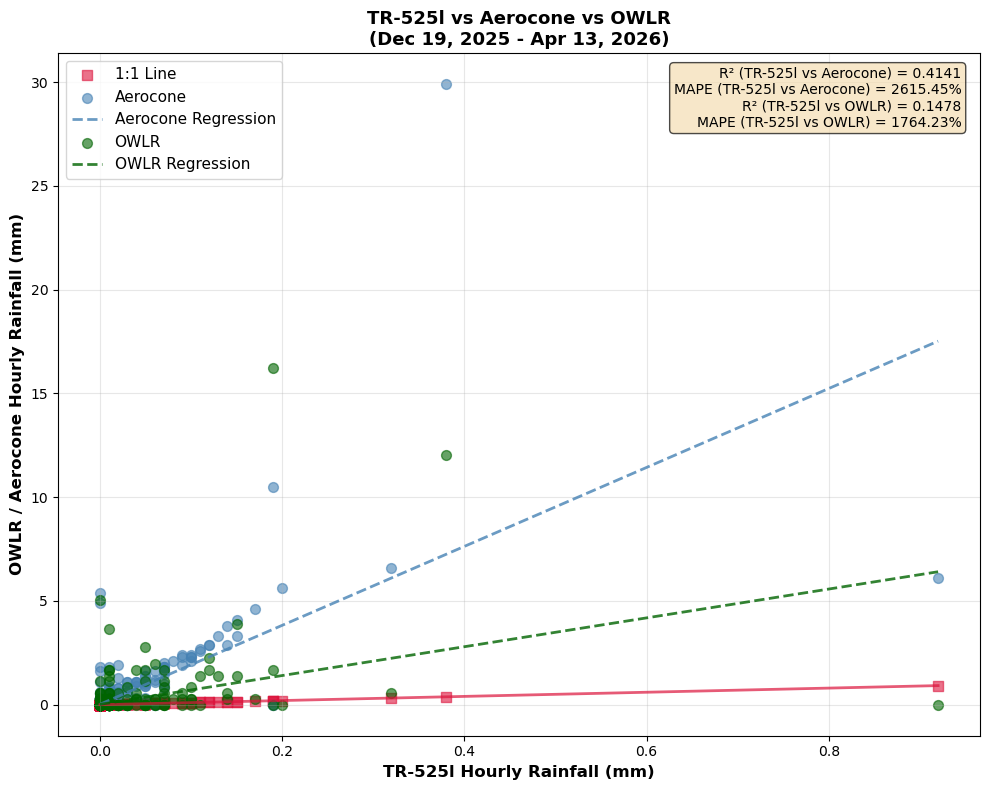

In [75]:
# TR525 (X-axis) vs Davis and OWLR (Y-axis) — Full Period Comparison
from scipy import stats

print('=' * 70)
print('FULL PERIOD ANALYSIS: TR525 vs Davis vs OWLR')
print('December 19th, 2025 - April 13th, 2026')
print('=' * 70)
print(f'\nData summary:')
print(f'  TR525 records: {len(cormp)}')
print(f'  Davis records: {len(davis)}')
print(f'  OWLR records: {len(owlr)}')

def analyze_pair(df, y_col):
    pair = df[['tr525_mm', y_col]].dropna()
    if pair.empty:
        return pair, np.nan, np.nan, np.nan, np.nan, np.nan

    corr = pair['tr525_mm'].corr(pair[y_col])
    r2 = corr**2
    slope, intercept, _, _, _ = stats.linregress(pair['tr525_mm'], pair[y_col])

    nonzero = pair['tr525_mm'] != 0
    if nonzero.any():
        mape = np.mean(
            np.abs(
                (pair.loc[nonzero, 'tr525_mm'] - pair.loc[nonzero, y_col])
                / pair.loc[nonzero, 'tr525_mm']
            )
        ) * 100
    else:
        mape = np.nan

    return pair, corr, r2, slope, intercept, mape

merged_full = rainfall_all.copy()
print(f'\nMerged dataset shape: {merged_full.shape}')

cormp_davis_data, corr_cd, r2_cd, slope_cd, intercept_cd, mape_cd = analyze_pair(merged_full, 'aerocone_mm')
cormp_owlr_data, corr_co, r2_co, slope_co, intercept_co, mape_owlr = analyze_pair(merged_full, 'owlr_mm')

if not cormp_davis_data.empty:
    print(f'\nTR525 vs Davis:')
    print(f'  Pearson Correlation: {corr_cd:.4f}')
    print(f'  R²: {r2_cd:.4f}')
    print(f'  Slope: {slope_cd:.4f}')
    print(f"  MAPE: {mape_cd:.2f}%" if pd.notna(mape_cd) else '  MAPE: undefined')

if not cormp_owlr_data.empty:
    print(f'\nTR525 vs OWLR:')
    print(f'  Pearson Correlation: {corr_co:.4f}')
    print(f'  R²: {r2_co:.4f}')
    print(f'  Slope: {slope_co:.4f}')
    print(f"  MAPE: {mape_owlr:.2f}%" if pd.notna(mape_owlr) else '  MAPE: undefined')

print('\nGenerating scatter plot...')
plt.figure(figsize=(10, 8))

tr525_data = merged_full[['tr525_mm']].dropna().sort_values('tr525_mm')
if not tr525_data.empty:
    plt.scatter(tr525_data['tr525_mm'], tr525_data['tr525_mm'], s=50, alpha=0.6, color='crimson', label='1:1 Line', marker='s')
    plt.plot(tr525_data['tr525_mm'], tr525_data['tr525_mm'], color='crimson', linewidth=2, alpha=0.7)
    print(f'  Plotted {len(tr525_data)} TR525 data points')

plot_specs = [
    ('aerocone_mm', cormp_davis_data, slope_cd, intercept_cd, 'steelblue', 'Aerocone', 'Aerocone Regression'),
    ('owlr_mm', cormp_owlr_data, slope_co, intercept_co, 'darkgreen', 'OWLR', 'OWLR Regression')
]

all_x = merged_full['tr525_mm'].dropna()
x_line = np.array([all_x.min(), all_x.max()]) if not all_x.empty else None

for y_col, pair, slope, intercept, color, label, line_label in plot_specs:
    plot_df = merged_full[['tr525_mm', y_col]].dropna()
    if plot_df.empty:
        continue
    plt.scatter(plot_df['tr525_mm'], plot_df[y_col], s=50, alpha=0.6, color=color, label=label)
    print(f'  Plotted {len(plot_df)} {label} data points')
    if x_line is not None and not pair.empty:
        plt.plot(x_line, slope * x_line + intercept, color=color, linewidth=2, alpha=0.8, linestyle='--', label=line_label)

plt.xlabel('TR-525l Hourly Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('OWLR / Aerocone Hourly Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('TR-525l vs Aerocone vs OWLR\n(Dec 19, 2025 - Apr 13, 2026)', fontsize=13, fontweight='bold')

annotation_lines = [
    f'R² (TR-525l vs Aerocone) = {r2_cd:.4f}' if pd.notna(r2_cd) else None,
    f'MAPE (TR-525l vs Aerocone) = {mape_cd:.2f}%' if pd.notna(mape_cd) else 'MAPE (TR-525l vs Aerocone) = undefined',
    f'R² (TR-525l vs OWLR) = {r2_co:.4f}' if pd.notna(r2_co) else None,
    f'MAPE (TR-525l vs OWLR) = {mape_owlr:.2f}%' if pd.notna(mape_owlr) else 'MAPE (TR-525l vs OWLR) = undefined'
]
plt.gca().text(
    0.98,
    0.98,
    '\n'.join(line for line in annotation_lines if line is not None),
    transform=plt.gca().transAxes,
    fontsize=10,
    va='top',
    ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FULL PERIOD ANALYSIS: CORMP vs OWLR (+ Davis points)
December 19th, 2025 - Apr 13th, 2026

Data summary:
  CORMP records: 2760
  Davis records: 2760
  OWLR records: 2753

Merged dataset shape: (2765, 4)

CORMP vs OWLR:
  Pearson Correlation: 0.3844
  R²: 0.1478
  Slope: 6.9463

Generating scatter plot...
  Plotted 2765 CORMP points
  Plotted 2753 OWLR points
  Plotted 2765 Aerocone points


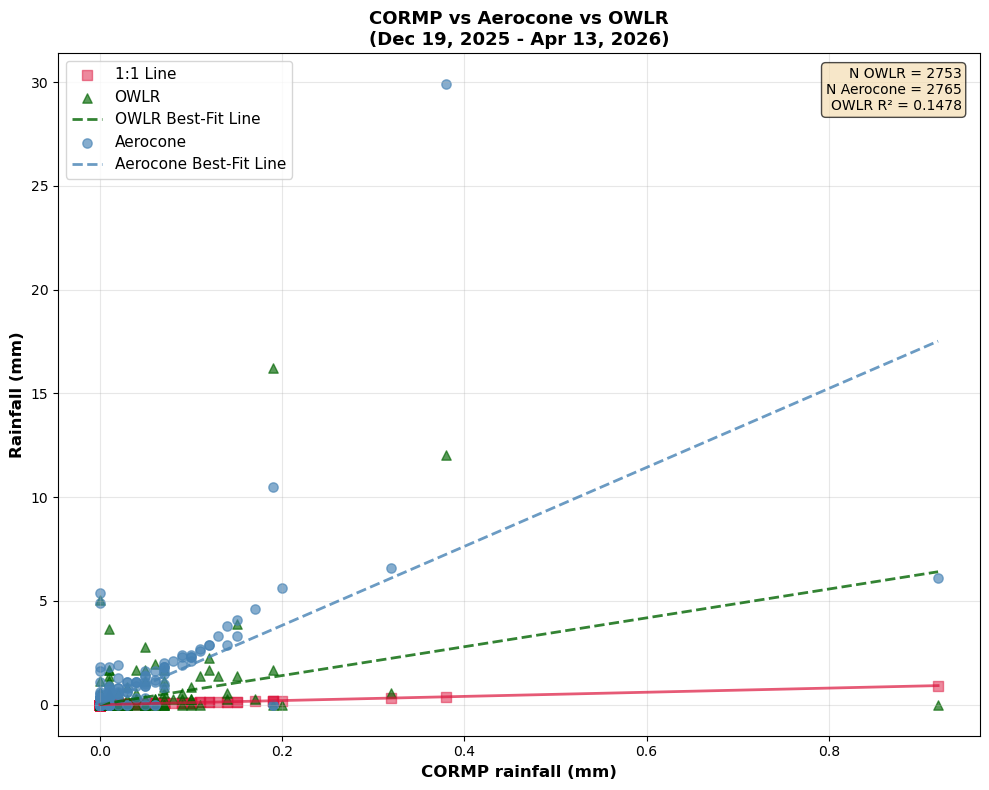

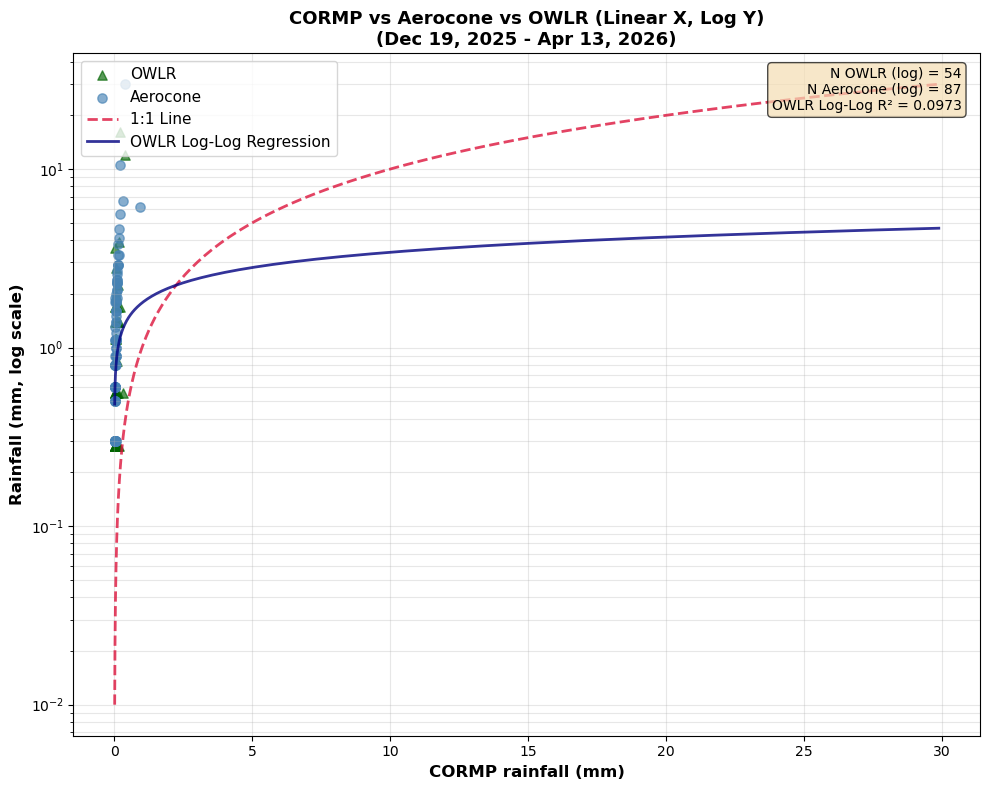

In [63]:
# CORMP (X-axis) vs OWLR and Davis (Y-axis) — Full Period Comparison
print('=' * 70)
print('FULL PERIOD ANALYSIS: CORMP vs OWLR (+ Davis points)')
print('December 19th, 2025 - Apr 13th, 2026')
print('=' * 70)

print(f'\nData summary:')
print(f'  CORMP records: {len(cormp)}')
print(f'  Davis records: {len(davis)}')
print(f'  OWLR records: {len(owlr)}')

merged_owlr_only = build_event_frame(start, end).rename(columns={'rain_mm_owlr': 'rain_mm_owlr_hourly'})
print(f'\nMerged dataset shape: {merged_owlr_only.shape}')

r2_owlr = float('nan')
owlr_pair = merged_owlr_only[
    merged_owlr_only['rain_mm_cormp'].notna() & merged_owlr_only['rain_mm_owlr_hourly'].notna()
]
if not owlr_pair.empty:
    corr_owlr = owlr_pair['rain_mm_cormp'].corr(owlr_pair['rain_mm_owlr_hourly'])
    r2_owlr = corr_owlr**2
    slope_owlr, intercept_owlr, _, _, _ = stats.linregress(
        owlr_pair['rain_mm_cormp'],
        owlr_pair['rain_mm_owlr_hourly']
    )
    print(f'\nCORMP vs OWLR:')
    print(f'  Pearson Correlation: {corr_owlr:.4f}')
    print(f'  R²: {r2_owlr:.4f}')
    print(f'  Slope: {slope_owlr:.4f}')

davis_pair = merged_owlr_only[
    merged_owlr_only['rain_mm_cormp'].notna() & merged_owlr_only['rain_mm_davis'].notna()
]

print('\nGenerating scatter plot...')
plt.figure(figsize=(10, 8))

cormp_pair = merged_owlr_only[['rain_mm_cormp']].dropna()
if not cormp_pair.empty:
    plt.scatter(
        cormp_pair['rain_mm_cormp'],
        cormp_pair['rain_mm_cormp'],
        s=45,
        alpha=0.5,
        color='crimson',
        label='1:1 Line',
        marker='s'
    )
    sorted_cormp = cormp_pair.sort_values('rain_mm_cormp')
    plt.plot(
        sorted_cormp['rain_mm_cormp'],
        sorted_cormp['rain_mm_cormp'],
        color='crimson',
        linewidth=2,
        alpha=0.7
    )
    print(f'  Plotted {len(cormp_pair)} CORMP points')

if not owlr_pair.empty:
    plt.scatter(
        owlr_pair['rain_mm_cormp'],
        owlr_pair['rain_mm_owlr_hourly'],
        s=45,
        alpha=0.65,
        color='darkgreen',
        label='OWLR',
        marker='^'
    )
    print(f'  Plotted {len(owlr_pair)} OWLR points')
    add_best_fit_line(plt.gca(), owlr_pair, 'rain_mm_cormp', 'rain_mm_owlr_hourly', 'darkgreen', 'OWLR Best-Fit Line')

if not davis_pair.empty:
    plt.scatter(
        davis_pair['rain_mm_cormp'],
        davis_pair['rain_mm_davis'],
        s=45,
        alpha=0.65,
        color='steelblue',
        label='Aerocone',
        marker='o'
    )
    print(f'  Plotted {len(davis_pair)} Aerocone points')
    add_best_fit_line(plt.gca(), davis_pair, 'rain_mm_cormp', 'rain_mm_davis', 'steelblue', 'Aerocone Best-Fit Line')

annotation = [
    f'N OWLR = {len(owlr_pair)}',
    f'N Aerocone = {len(davis_pair)}'
]
if pd.notna(r2_owlr):
    annotation.append(f'OWLR R² = {r2_owlr:.4f}')
plt.gca().text(
    0.98,
    0.98,
    '\n'.join(annotation),
    transform=plt.gca().transAxes,
    fontsize=10,
    va='top',
    ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
)

plt.xlabel('CORMP rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('CORMP vs Aerocone vs OWLR\n(Dec 19, 2025 - Apr 13, 2026)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

positive_pairs_owlr = owlr_pair[
    (owlr_pair['rain_mm_cormp'] > 0) & (owlr_pair['rain_mm_owlr_hourly'] > 0)
]
positive_pairs_davis = davis_pair[
    (davis_pair['rain_mm_cormp'] > 0) & (davis_pair['rain_mm_davis'] > 0)
]

if not positive_pairs_owlr.empty and not positive_pairs_davis.empty:
    plt.figure(figsize=(10, 8))
    plt.scatter(
        positive_pairs_owlr['rain_mm_cormp'],
        positive_pairs_owlr['rain_mm_owlr_hourly'],
        s=45,
        alpha=0.65,
        color='darkgreen',
        label='OWLR',
        marker='^'
    )
    plt.scatter(
        positive_pairs_davis['rain_mm_cormp'],
        positive_pairs_davis['rain_mm_davis'],
        s=45,
        alpha=0.65,
        color='steelblue',
        label='Aerocone',
        marker='o'
    )

    positive_x_values = positive_pairs_owlr['rain_mm_cormp'].tolist() + positive_pairs_davis['rain_mm_cormp'].tolist()
    positive_y_values = positive_pairs_owlr['rain_mm_owlr_hourly'].tolist() + positive_pairs_davis['rain_mm_davis'].tolist()
    min_val = min(min(positive_x_values), min(positive_y_values))
    max_val = max(max(positive_x_values), max(positive_y_values))
    reference_line = np.logspace(np.log10(min_val), np.log10(max_val), 200)
    plt.plot(
        reference_line,
        reference_line,
        color='crimson',
        linewidth=2,
        alpha=0.8,
        linestyle='--',
        label='1:1 Line'
    )

    r2_log = float('nan')
    if len(positive_pairs_owlr) >= 2:
        log_x = np.log10(positive_pairs_owlr['rain_mm_cormp'])
        log_y = np.log10(positive_pairs_owlr['rain_mm_owlr_hourly'])
        slope_log, intercept_log, r_value_log, _, _ = stats.linregress(log_x, log_y)
        regression_line = 10 ** (intercept_log + slope_log * np.log10(reference_line))
        plt.plot(
            reference_line,
            regression_line,
            color='navy',
            linewidth=2,
            alpha=0.8,
            label='OWLR Log-Log Regression'
        )
        r2_log = r_value_log**2

    annotation = [
        f'N OWLR (log) = {len(positive_pairs_owlr)}',
        f'N Aerocone (log) = {len(positive_pairs_davis)}'
]
    if pd.notna(r2_log):
        annotation.append(f'OWLR Log-Log R² = {r2_log:.4f}')
    ax = plt.gca()
    ax.text(
        0.98,
        0.98,
        '\n'.join(annotation),
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    )

    plt.yscale('log')
    plt.xlabel('CORMP rainfall (mm)', fontsize=12, fontweight='bold')
    plt.ylabel('Rainfall (mm, log scale)', fontsize=12, fontweight='bold')
    plt.title('CORMP vs Aerocone vs OWLR (Linear X, Log Y)\n(Dec 19, 2025 - Apr 13, 2026)', fontsize=13, fontweight='bold')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()

Filtering January 3rd data...
  CORMP: 24 hourly records
  Davis: 24 hourly records
  OWLR: 24 hourly records


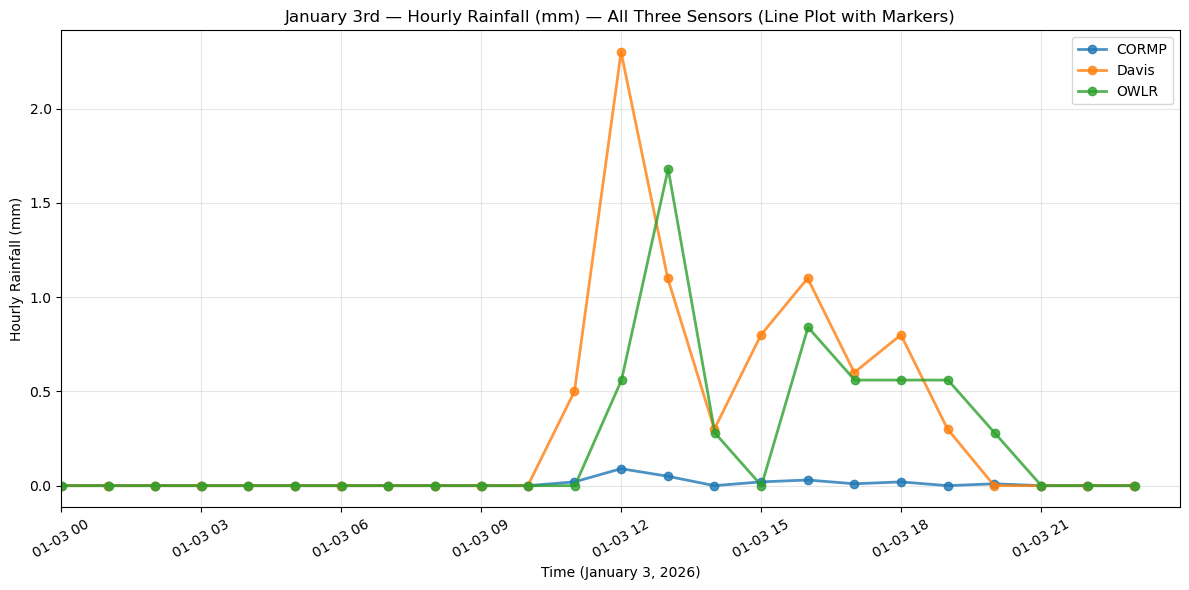

In [76]:
# View of January 3rd, 2026 — All three sensors
jan3_start = pd.to_datetime('2026-01-03 00:00')
jan3_end = pd.to_datetime('2026-01-03 23:59')

print('Filtering January 3rd data...')
cormp_jan3 = cormp[(cormp['datetime'] >= jan3_start) & (cormp['datetime'] <= jan3_end)].reset_index(drop=True)
davis_jan3 = davis[(davis['datetime'] >= jan3_start) & (davis['datetime'] <= jan3_end)].reset_index(drop=True)
owlr_jan3 = owlr[(owlr['datetime'] >= jan3_start) & (owlr['datetime'] <= jan3_end)].reset_index(drop=True)

print(f'  CORMP: {len(cormp_jan3)} hourly records')
print(f'  Davis: {len(davis_jan3)} hourly records')
print(f'  OWLR: {len(owlr_jan3)} hourly records')

plt.figure(figsize=(12, 6))
if not cormp_jan3.empty:
    plt.plot(cormp_jan3['datetime'], cormp_jan3['rain_mm'], label='CORMP', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not davis_jan3.empty:
    plt.plot(davis_jan3['datetime'], davis_jan3['rain_mm'], label='Davis', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not owlr_jan3.empty:
    plt.plot(owlr_jan3['datetime'], owlr_jan3['rain_mm'], label='OWLR', marker='o', linewidth=2, markersize=6, alpha=0.8)

plt.xlabel('Time (January 3, 2026)')
plt.ylabel('Hourly Rainfall (mm)')
plt.title('January 3rd — Hourly Rainfall (mm) — All Three Sensors (Line Plot with Markers)')
plt.legend()
plt.xlim(jan3_start, jan3_end)
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Direct comparison between TR525l and OWLR with adjusted points. 

Overlapping hourly points (OWLR): 2753
Overlapping hourly points (Aerocone): 2765
Calibration equation: OWLR_cal = 0.0213 * OWLR_raw + 0.0018
R^2 (raw OWLR vs TR-525l): 0.1478
R^2 (calibrated OWLR vs TR-525l): 0.1478
RMSE raw: 0.4253 mm
RMSE calibrated: 0.0221 mm
R^2 (Aerocone vs TR-525l): 0.4141
RMSE Aerocone: 0.6944 mm


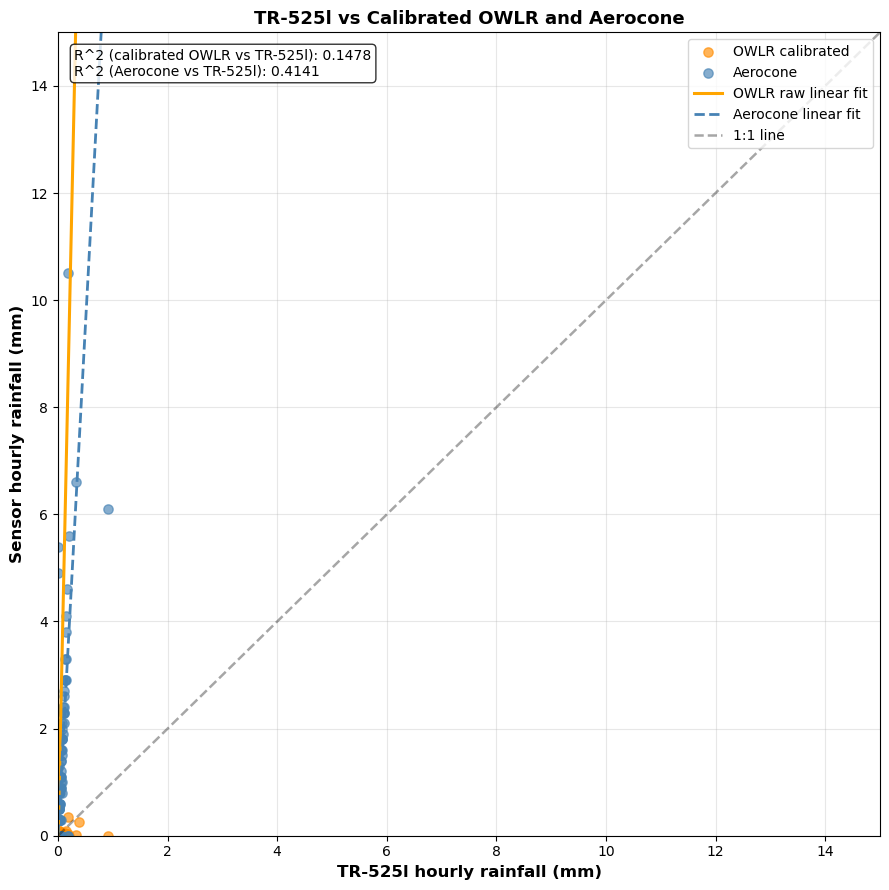

In [52]:
# Direct comparison: TR-525l (reference) vs OWLR, then calibrate OWLR, with Aerocone overlay

from scipy import stats

# Timeframe
start_cmp = pd.to_datetime('2025-12-19 09:00')
end_cmp = pd.to_datetime('2026-04-15 08:00')

comparison_base = build_event_frame(start_cmp, end_cmp)
compare_df = comparison_base[['datetime', 'rain_mm_cormp', 'rain_mm_owlr']].dropna().rename(
    columns={'rain_mm_cormp': 'rain_mm_tr525l', 'rain_mm_owlr': 'rain_mm_owlr'}
)
compare_df_aero = comparison_base[['datetime', 'rain_mm_cormp', 'rain_mm_davis']].dropna().rename(
    columns={'rain_mm_cormp': 'rain_mm_tr525l', 'rain_mm_davis': 'rain_mm_davis'}
)

print(f"Overlapping hourly points (OWLR): {len(compare_df)}")
print(f"Overlapping hourly points (Aerocone): {len(compare_df_aero)}")

if len(compare_df) < 2:
    print('Not enough OWLR points for calibration regression.')
else:
    # Fit calibration model on overlapping original measurements:
    # TR-525l = m * OWLR_raw + b
    x_owlr_raw = compare_df['rain_mm_owlr']
    y_tr525l = compare_df['rain_mm_tr525l']

    m, b, r_raw, p_raw, se_raw = stats.linregress(x_owlr_raw, y_tr525l)
    r2_raw = r_raw ** 2

    # Apply calibration to OWLR only
    owlr_cal = (m * x_owlr_raw) + b

    # Metrics against TR-525l reference
    r_cal = y_tr525l.corr(owlr_cal)
    r2_cal = r_cal ** 2 if pd.notna(r_cal) else float('nan')

    rmse_raw = np.sqrt(np.mean((x_owlr_raw - y_tr525l) ** 2))
    rmse_cal = np.sqrt(np.mean((owlr_cal - y_tr525l) ** 2))

    print(f"Calibration equation: OWLR_cal = {m:.4f} * OWLR_raw + {b:.4f}")
    print(f"R^2 (raw OWLR vs TR-525l): {r2_raw:.4f}")
    print(f"R^2 (calibrated OWLR vs TR-525l): {r2_cal:.4f}")
    print(f"RMSE raw: {rmse_raw:.4f} mm")
    print(f"RMSE calibrated: {rmse_cal:.4f} mm")

    r2_aero = float('nan')
    if len(compare_df_aero) >= 2:
        r_aero = compare_df_aero['rain_mm_davis'].corr(compare_df_aero['rain_mm_tr525l'])
        r2_aero = r_aero ** 2 if pd.notna(r_aero) else float('nan')
        rmse_aero = np.sqrt(np.mean((compare_df_aero['rain_mm_davis'] - compare_df_aero['rain_mm_tr525l']) ** 2))
        print(f"R^2 (Aerocone vs TR-525l): {r2_aero:.4f}")
        print(f"RMSE Aerocone: {rmse_aero:.4f} mm")

    plt.figure(figsize=(9, 9))
    plt.scatter(y_tr525l, owlr_cal, s=45, alpha=0.65, color='darkorange', label='OWLR calibrated')

    if not compare_df_aero.empty:
        plt.scatter(
            compare_df_aero['rain_mm_tr525l'],
            compare_df_aero['rain_mm_davis'],
            s=45,
            alpha=0.65,
            color='steelblue',
            label='Aerocone'
        )

    # Best-fit line using raw relationship
    x_line = np.linspace(y_tr525l.min(), y_tr525l.max(), 200)
    y_line = (x_line - b) / m if not np.isclose(m, 0.0) else np.full_like(x_line, np.nan)
    plt.plot(x_line, y_line, color='orange', linewidth=2.2, label='OWLR raw linear fit')

    # Optional Aerocone best-fit line
    if len(compare_df_aero) >= 2:
        slope_aero, intercept_aero, _, _, _ = stats.linregress(
            compare_df_aero['rain_mm_tr525l'],
            compare_df_aero['rain_mm_davis']
        )
        y_line_aero = slope_aero * x_line + intercept_aero
        plt.plot(x_line, y_line_aero, color='steelblue', linewidth=2.0, linestyle='--', label='Aerocone linear fit')

    # Clip axis range for readability in dense low-rain region
    clip_max = 15.0
    plt.plot([0, clip_max], [0, clip_max], 'k--', alpha=0.35, linewidth=1.8, label='1:1 line')
    plt.xlim(0, clip_max)
    plt.ylim(0, clip_max)

    plt.xlabel('TR-525l hourly rainfall (mm)', fontsize=12, fontweight='bold')
    plt.ylabel('Sensor hourly rainfall (mm)', fontsize=12, fontweight='bold')
    plt.title('TR-525l vs Calibrated OWLR and Aerocone', fontsize=13, fontweight='bold')

    # Plot annotation: R^2 values only.
    annotation_lines = [
        f'R^2 (calibrated OWLR vs TR-525l): {r2_cal:.4f}'
    ]
    if pd.notna(r2_aero):
        annotation_lines.append(f'R^2 (Aerocone vs TR-525l): {r2_aero:.4f}')
    ax = plt.gca()
    ax.text(
        0.02,
        0.98,
        '\n'.join(annotation_lines),
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        ha='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

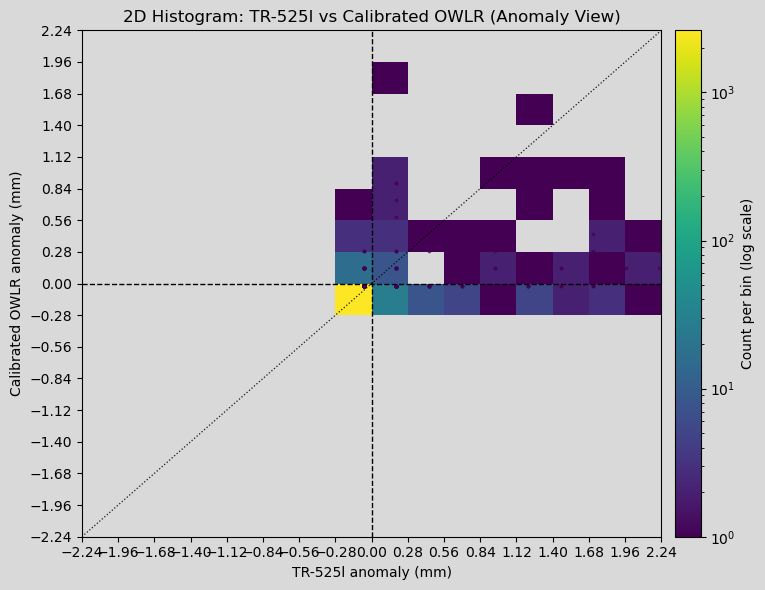

In [ ]:
# 2D histogram: anomaly-centered view to match reference photo style
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm

if 'compare_df' not in locals() or compare_df.empty:
    raise ValueError('Run Cell 25 first to create compare_df and calibration values.')

coeff_m = globals().get('m')
coeff_b = globals().get('b')
if coeff_m is None or coeff_b is None:
    x_owlr_raw = compare_df['rain_mm_owlr']
    y_tr525l = compare_df['rain_mm_tr525l']
    coeff_m, coeff_b, _, _, _ = stats.linregress(x_owlr_raw, y_tr525l)

x_raw = compare_df['rain_mm_tr525l'].to_numpy()
y_raw = (coeff_m * compare_df['rain_mm_owlr'] + coeff_b).to_numpy()

valid = np.isfinite(x_raw) & np.isfinite(y_raw)
x_raw = x_raw[valid]
y_raw = y_raw[valid]

if len(x_raw) < 2:
    raise ValueError('Not enough valid points for 2D histogram.')

# Center data to create the same visual style as the reference image.
x = x_raw - np.nanmean(x_raw)
y = y_raw - np.nanmean(y_raw)

tick_step = 0.28
abs_all = np.abs(np.concatenate([x, y]))
lim_data = float(np.nanpercentile(abs_all, 99.5))
axis_lim = max(tick_step * 8, tick_step * np.ceil((lim_data * 1.1) / tick_step))

bin_step = tick_step
edges = np.arange(-axis_lim, axis_lim + bin_step, bin_step)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#d9d9d9')
ax.set_facecolor('#d9d9d9')

hist = ax.hist2d(
    x,
    y,
    bins=[edges, edges],
    range=[[-axis_lim, axis_lim], [-axis_lim, axis_lim]],
    cmap='viridis',
    norm=LogNorm(vmin=1)
 )
cbar = plt.colorbar(hist[3], ax=ax, pad=0.02)
cbar.set_label('Count per bin (log scale)')

# Overlay points for the same texture as the reference plot.
ax.scatter(x, y, s=7, color='#440154', alpha=0.75, linewidths=0, zorder=2)

# Zero crosshairs and 1:1 line through the origin.
ax.axvline(0, color='black', linestyle='--', linewidth=1.0, zorder=3)
ax.axhline(0, color='black', linestyle='--', linewidth=1.0, zorder=3)
ax.plot([-axis_lim, axis_lim], [-axis_lim, axis_lim], color='black', linestyle=':', linewidth=0.9, alpha=0.9, zorder=3)

ax.set_xlim(-axis_lim, axis_lim)
ax.set_ylim(-axis_lim, axis_lim)
ax.xaxis.set_major_locator(MultipleLocator(tick_step))
ax.yaxis.set_major_locator(MultipleLocator(tick_step))

ax.set_xlabel('TR-525l anomaly (mm)')
ax.set_ylabel('Calibrated OWLR anomaly (mm)')
ax.set_title('2D Histogram: TR-525l vs Calibrated OWLR (Anomaly View)')

plt.tight_layout()
plt.show()

# Rainfall Event Plots

The following plots show analysis from specific rain events during deployment. 



ANALYSIS 5: January 18th, 2026 — CORMP vs Davis and calibrated OWLR

January 18th, 2026 Data:
  CORMP records: 12
  Davis records: 12
  OWLR calibrated records: 12

Merged dataset shape: (12, 5)

Generating scatter plot...
  Plotted 12 TR525l data points
  Plotted 12 Aerocone data points
  Plotted 12 OWLR calibrated data points


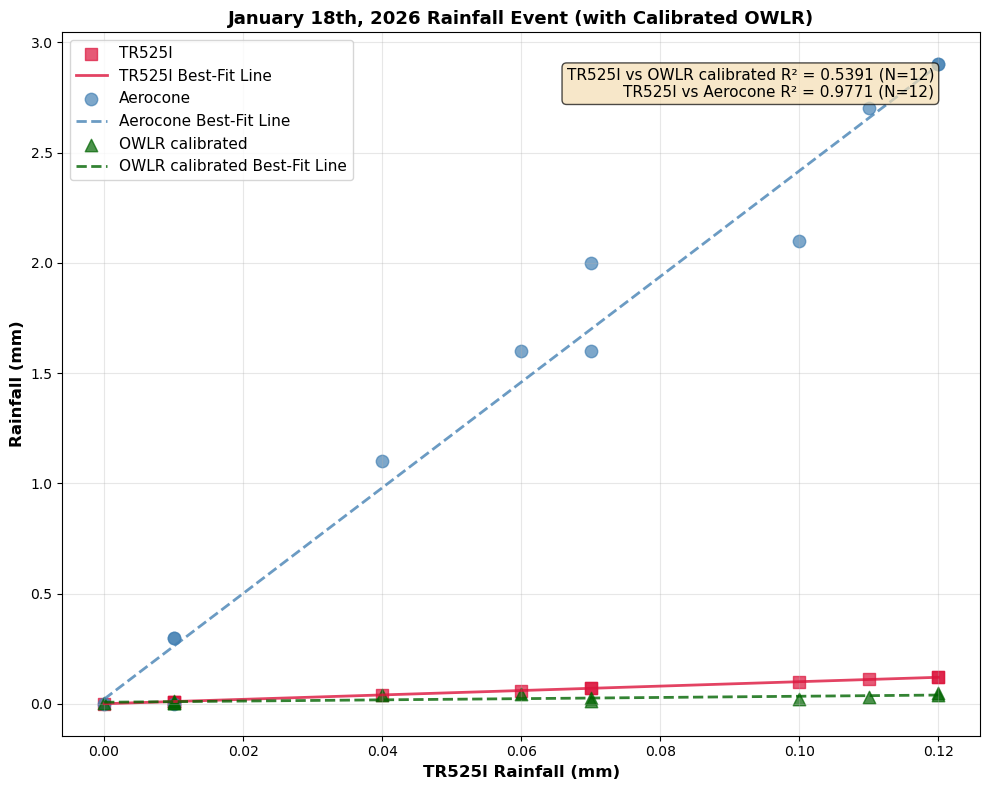


Summary Statistics for January 18th, 2026:
CORMP - Min: 0.0000, Max: 0.1200, Mean: 0.0600
Davis - Min: 0.0000, Max: 2.9000, Mean: 1.4583
OWLR calibrated - Min: 0.0018, Max: 0.0494, Mean: 0.0231


In [77]:
# January 18th, 2026 — CORMP vs Davis and calibrated OWLR Comparison
jan18_start = pd.to_datetime('2026-01-18 08:00')
jan18_end = pd.to_datetime('2026-01-18 19:00')

merged_jan18 = build_event_frame(jan18_start, jan18_end, calibrate_owlr=True)
run_event_analysis(
    analysis_title='ANALYSIS 5: January 18th, 2026 — CORMP vs Davis and calibrated OWLR',
    event_label='January 18th, 2026',
    event_df=merged_jan18,
    plot_title='January 18th, 2026 Rainfall Event (with Calibrated OWLR)',
    owlr_col='rain_mm_owlr_cal',
    owlr_label='OWLR calibrated'
 )

ANALYSIS 6: January 3rd 9am - 11pm — CORMP vs Davis and OWLR

January 3rd 9am - 11pm Data:
  CORMP records: 15
  Davis records: 15
  OWLR records: 15

Merged dataset shape: (15, 4)

Generating scatter plot...
  Plotted 15 TR525l data points
  Plotted 15 Aerocone data points
  Plotted 15 OWLR data points


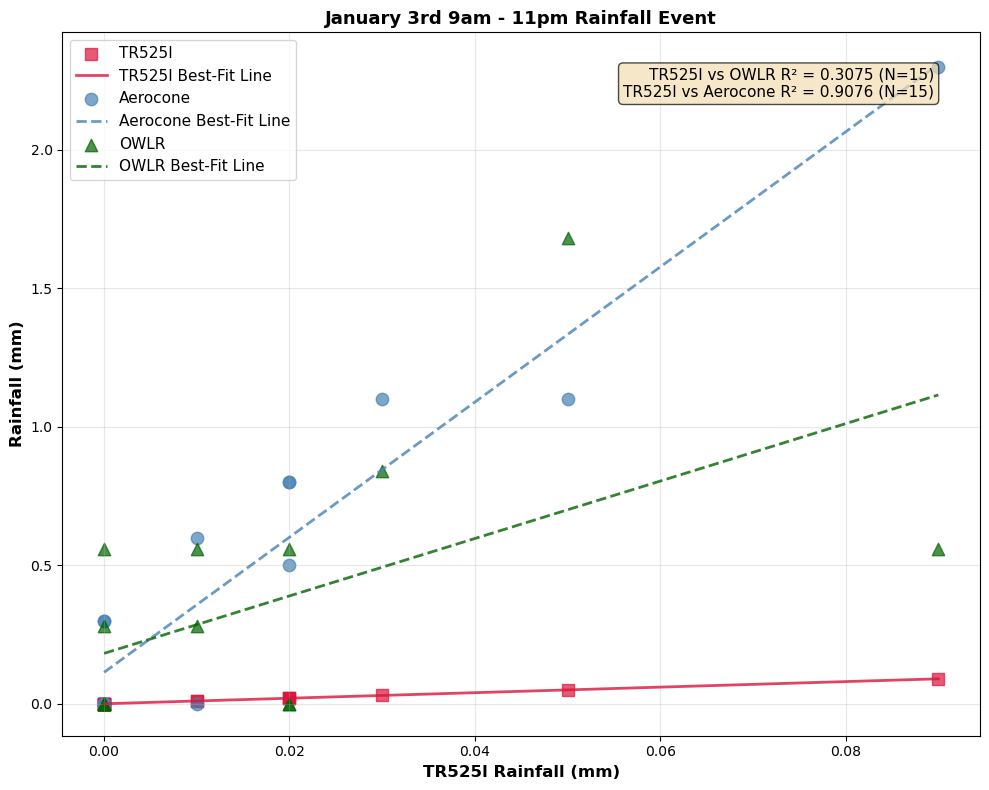


Summary Statistics for January 3rd 9am - 11pm:
CORMP - Min: 0.0000, Max: 0.0900, Mean: 0.0167
Davis - Min: 0.0000, Max: 2.3000, Mean: 0.5200
OWLR - Min: 0.0000, Max: 1.6800, Mean: 0.3547


In [78]:
# January 3rd 9am to 11pm — CORMP vs Davis and OWLR Comparison
jan3_start = pd.to_datetime('2026-01-03 09:00')
jan3_end = pd.to_datetime('2026-01-03 23:00')

merged_jan3 = build_event_frame(jan3_start, jan3_end)
run_event_analysis(
    analysis_title='ANALYSIS 6: January 3rd 9am - 11pm — CORMP vs Davis and OWLR',
    event_label='January 3rd 9am - 11pm',
    event_df=merged_jan3,
    plot_title='January 3rd 9am - 11pm Rainfall Event',
    owlr_col='rain_mm_owlr',
    owlr_label='OWLR'
 )

ANALYSIS 7: January 25th 7am - January 26th 11am — CORMP vs Davis and OWLR

January 25th 7am - January 26th 11am Data:
  CORMP records: 29
  Davis records: 29
  OWLR records: 29

Merged dataset shape: (29, 4)

Generating scatter plot...
  Plotted 29 TR525l data points
  Plotted 29 Aerocone data points
  Plotted 29 OWLR data points


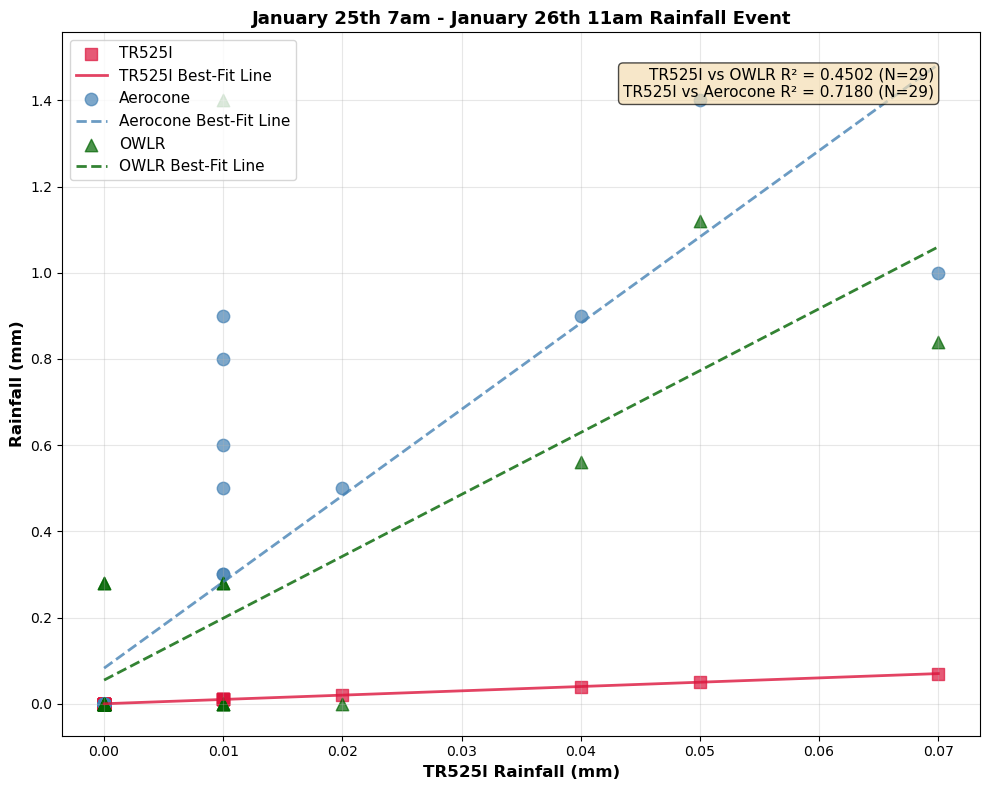


Summary Statistics for January 25th 7am - January 26th 11am:
CORMP - Min: 0.0000, Max: 0.0700, Mean: 0.0083
Davis - Min: 0.0000, Max: 1.4000, Mean: 0.2483
OWLR - Min: 0.0000, Max: 1.4000, Mean: 0.1738


In [64]:
# January 25th 7am to January 26th 11am — CORMP vs Davis and OWLR Comparison
jan25_start = pd.to_datetime('2026-01-25 07:00')
jan26_end = pd.to_datetime('2026-01-26 11:00')

merged_jan25_26 = build_event_frame(jan25_start, jan26_end)
run_event_analysis(
    analysis_title='ANALYSIS 7: January 25th 7am - January 26th 11am — CORMP vs Davis and OWLR',
    event_label='January 25th 7am - January 26th 11am',
    event_df=merged_jan25_26,
    plot_title='January 25th 7am - January 26th 11am Rainfall Event',
    owlr_col='rain_mm_owlr',
    owlr_label='OWLR'
 )

ANALYSIS 8: February 4th 2pm - February 5th 8am — TR525l vs Aerocone and calibrated OWLR

February 4th 2pm - February 5th 8am Data:
  CORMP records: 19
  Davis records: 19
  OWLR calibrated records: 19

Merged dataset shape: (19, 5)

Generating scatter plot...
  Plotted 19 TR525l data points
  Plotted 19 Aerocone data points
  Plotted 19 OWLR calibrated data points


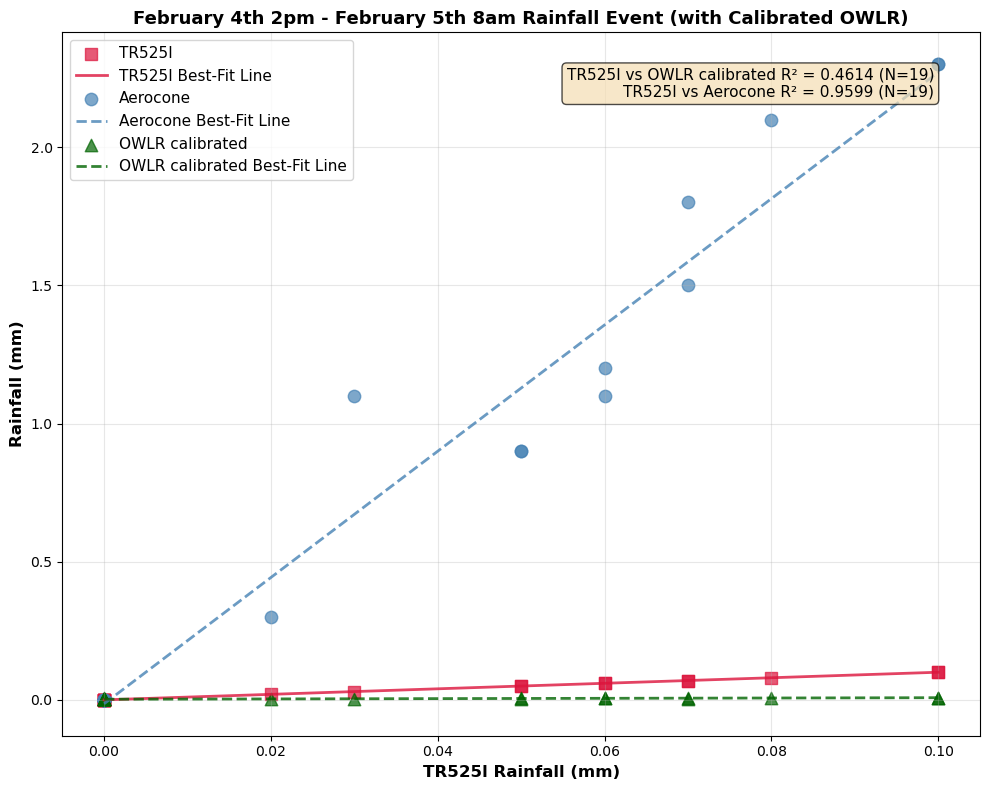


Summary Statistics for February 4th 2pm - February 5th 8am:
CORMP - Min: 0.0000, Max: 0.1000, Mean: 0.0363
Davis - Min: 0.0000, Max: 2.3000, Mean: 0.8158
OWLR calibrated - Min: 0.0018, Max: 0.0077, Mean: 0.0043


In [65]:
# February 4th 2pm to February 5th 8am — TR525l vs Aerocone and calibrated OWLR Comparison
feb4_start = pd.to_datetime('2026-02-04 14:00')
feb5_end = pd.to_datetime('2026-02-05 08:00')

merged_feb4_5 = build_event_frame(feb4_start, feb5_end, calibrate_owlr=True)
run_event_analysis(
    analysis_title='ANALYSIS 8: February 4th 2pm - February 5th 8am — TR525l vs Aerocone and calibrated OWLR',
    event_label='February 4th 2pm - February 5th 8am',
    event_df=merged_feb4_5,
    plot_title='February 4th 2pm - February 5th 8am Rainfall Event (with Calibrated OWLR)',
    owlr_col='rain_mm_owlr_cal',
    owlr_label='OWLR calibrated'
 )

ANALYSIS 9: February 15th 12am - February 17th 12am — CORMP vs Davis and calibrated OWLR

February 15th 12am - February 17th 12am Data:
  CORMP records: 49
  Davis records: 49
  OWLR calibrated records: 49

Merged dataset shape: (49, 5)

Generating scatter plot...
  Plotted 49 TR525l data points
  Plotted 49 Aerocone data points
  Plotted 49 OWLR calibrated data points


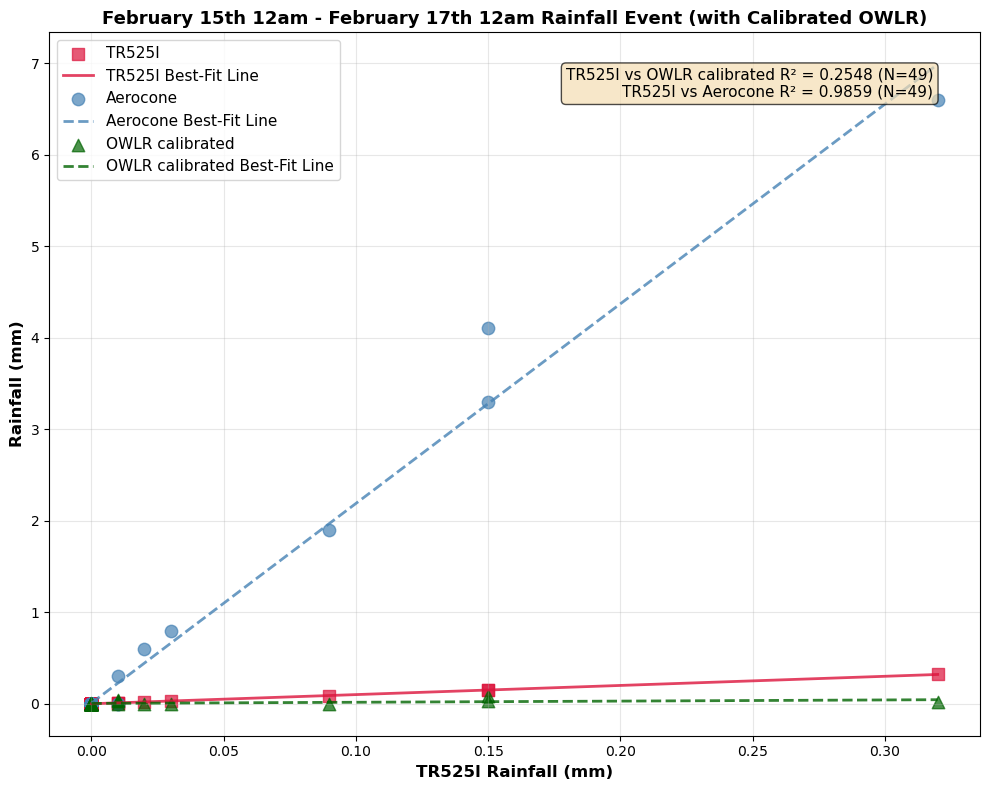


Summary Statistics for February 15th 12am - February 17th 12am:
CORMP - Min: 0.0000, Max: 0.3200, Mean: 0.0161
Davis - Min: 0.0000, Max: 6.6000, Mean: 0.3592
OWLR calibrated - Min: 0.0018, Max: 0.0850, Mean: 0.0057


In [66]:
# February 15th 12am to February 17th 12am — CORMP vs Davis and calibrated OWLR Comparison
feb15_start = pd.to_datetime('2026-02-15 00:00')
feb17_end = pd.to_datetime('2026-02-17 00:00')

merged_feb15_17 = build_event_frame(feb15_start, feb17_end, calibrate_owlr=True)
run_event_analysis(
    analysis_title='ANALYSIS 9: February 15th 12am - February 17th 12am — CORMP vs Davis and calibrated OWLR',
    event_label='February 15th 12am - February 17th 12am',
    event_df=merged_feb15_17,
    plot_title='February 15th 12am - February 17th 12am Rainfall Event (with Calibrated OWLR)',
    owlr_col='rain_mm_owlr_cal',
    owlr_label='OWLR calibrated'
 )

ANALYSIS 10: March 15th 8pm - March 17th 8am — CORMP vs Davis and OWLR

March 15th 8pm - March 17th 8am Data:
  CORMP records: 37
  Davis records: 37
  OWLR records: 37

Merged dataset shape: (37, 4)

Generating scatter plot...
  Plotted 37 TR525l data points
  Plotted 37 Aerocone data points
  Plotted 37 OWLR data points


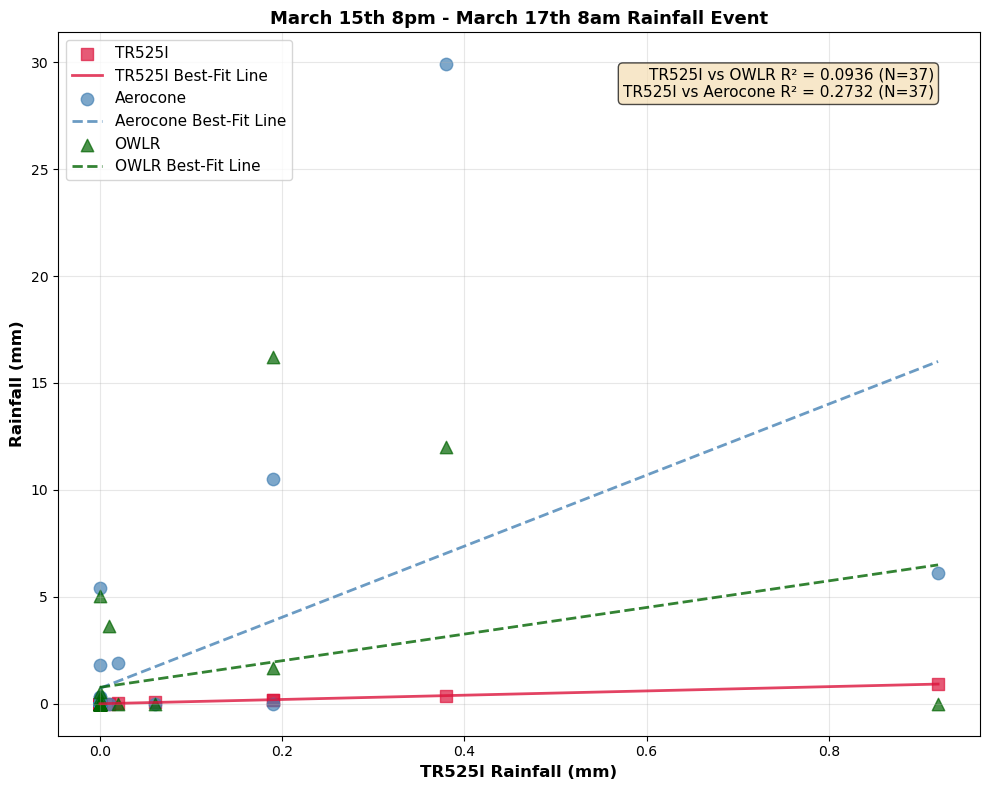


Summary Statistics for March 15th 8pm - March 17th 8am:
CORMP - Min: 0.0000, Max: 0.9200, Mean: 0.0478
Davis - Min: 0.0000, Max: 29.9000, Mean: 1.5189
OWLR - Min: 0.0000, Max: 16.2100, Mean: 1.0649


In [67]:
# March 15th 8pm to March 17th 8am — CORMP vs Davis and OWLR Comparison
mar15_start = pd.to_datetime('2026-03-15 20:00')
mar17_end = pd.to_datetime('2026-03-17 08:00')

merged_mar15_17 = build_event_frame(mar15_start, mar17_end)
run_event_analysis(
    analysis_title='ANALYSIS 10: March 15th 8pm - March 17th 8am — CORMP vs Davis and OWLR',
    event_label='March 15th 8pm - March 17th 8am',
    event_df=merged_mar15_17,
    plot_title='March 15th 8pm - March 17th 8am Rainfall Event',
    owlr_col='rain_mm_owlr',
    owlr_label='OWLR'
 )